# Customer Segmentation Analysis

## Objective

The objective of this notebook is to identify meaningful customer segments using both traditional RFM (Recency, Frequency, Monetary) analysis and unsupervised machine learning.

The analysis supports targeted marketing, customer retention strategies, loyalty programs, and executive decision-making by grouping customers according to purchasing behavior.

---

### Techniques Used

- Customer 360 Analytics
- RFM Analysis
- Customer Segmentation
- KMeans Clustering
- PCA Visualization
- Business Profiling

---

### Dataset

`data/processed/customer/customer_360.csv`

In [52]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.style.use("default")
from pathlib import Path

sns.set_theme(style="whitegrid")

In [53]:
from pathlib import Path

# Project Root
PROJECT_ROOT = Path("..")

# Reports Folder
REPORTS_DIR = PROJECT_ROOT / "reports"

# Figures Folder
FIGURES_DIR = REPORTS_DIR / "figures"

# Create folders if they don't exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(FIGURES_DIR.resolve())

/Users/sahil_jangid/codes/Main_projects/data_analytics/resume/retail-consumer-intelligence-platform/reports/figures


In [54]:
def save_plot(filename):

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved → {filename}.png")

    plt.show()

    plt.close()

In [55]:
customer = pd.read_csv(
    "../data/processed/customer/customer_360.csv",
    parse_dates=[
        "first_purchase",
        "last_purchase"
    ]
)

customer.head()

,customer_unique_id,customer_id,customer_city,customer_state,first_purchase,last_purchase,customer_lifetime_days,total_orders,total_products,total_spent,average_order_value,purchase_frequency,repeat_customer,average_review_score,preferred_payment_type
0,7c396fd4830fd04220f754e42b4e5bff,9ef432eb6251297304e76186b10a928d,sao paulo,SP,2017-09-04 11:26:38,2017-10-02 10:56:33,27,2,2,82.82,41.41,0.0741,True,4.5,credit_card
1,af07308b275d755c9edb36a90c618231,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,2018-07-24 20:41:37,2018-07-24 20:41:37,0,1,1,141.46,141.46,1.0000,False,4.0,boleto
2,3a653a41f6f9fc3d2a113cf8398680e8,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,2018-08-08 08:38:49,2018-08-08 08:38:49,0,1,1,179.12,179.12,1.0000,False,5.0,credit_card
3,7c142cf63193a1473d2e66489a9ae977,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN,2017-11-18 19:28:06,2017-11-18 19:28:06,0,1,1,72.20,72.20,1.0000,False,5.0,credit_card
4,72632f0f9dd73dfee390c9b22eb56dd6,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP,2018-02-13 21:18:39,2018-02-13 21:18:39,0,1,1,28.62,28.62,1.0000,False,5.0,credit_card


In [56]:
customer.shape

(96096, 15)

In [57]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_unique_id      96096 non-null  str           
 1   customer_id             96096 non-null  str           
 2   customer_city           96096 non-null  str           
 3   customer_state          96096 non-null  str           
 4   first_purchase          96096 non-null  datetime64[us]
 5   last_purchase           96096 non-null  datetime64[us]
 6   customer_lifetime_days  96096 non-null  int64         
 7   total_orders            96096 non-null  int64         
 8   total_products          96096 non-null  int64         
 9   total_spent             96096 non-null  float64       
 10  average_order_value     96095 non-null  float64       
 11  purchase_frequency      96096 non-null  float64       
 12  repeat_customer         96096 non-null  bool          
 1

In [58]:
customer.isna().sum()

customer_unique_id          0
customer_id                 0
customer_city               0
customer_state              0
first_purchase              0
last_purchase               0
customer_lifetime_days      0
total_orders                0
total_products              0
total_spent                 0
average_order_value         1
purchase_frequency          0
repeat_customer             0
average_review_score      716
preferred_payment_type      1
dtype: int64

In [59]:
customer.describe().T

,count,mean,min,25%,50%,75%,max,std
first_purchase,96096,2017-12-30 19:19:10.429206,2016-09-04 21:15:19,2017-09-11 19:52:06,2018-01-18 13:33:08,2018-05-04 10:38:45,2018-10-17 17:30:18,NaN
last_purchase,96096,2018-01-02 12:40:19.655864,2016-09-04 21:15:19,2017-09-15 09:04:17.250000,2018-01-21 19:39:16,2018-05-06 20:14:49.750000,2018-10-17 17:30:18,NaN
customer_lifetime_days,96096.0,2.711507,0.0,0.0,0.0,0.0,633.0,25.393343
total_orders,96096.0,1.034809,1.0,1.0,1.0,1.0,17.0,0.214384
total_products,96096.0,1.172265,0.0,1.0,1.0,1.0,24.0,0.627071
total_spent,96096.0,213.023712,0.0,63.99,113.15,202.7325,109312.64,640.917083
average_order_value,96095.0,161.539532,0.0,62.48,105.86,177.36,13664.08,222.463145
purchase_frequency,96096.0,0.990012,0.0033,1.0,1.0,1.0,6.0,0.171763
average_review_score,95380.0,4.084671,1.0,4.0,5.0,5.0,5.0,1.342089


In [60]:
snapshot_date = customer["last_purchase"].max() + pd.Timedelta(days=1)

customer["recency_days"] = (
    snapshot_date - customer["last_purchase"]
).dt.days

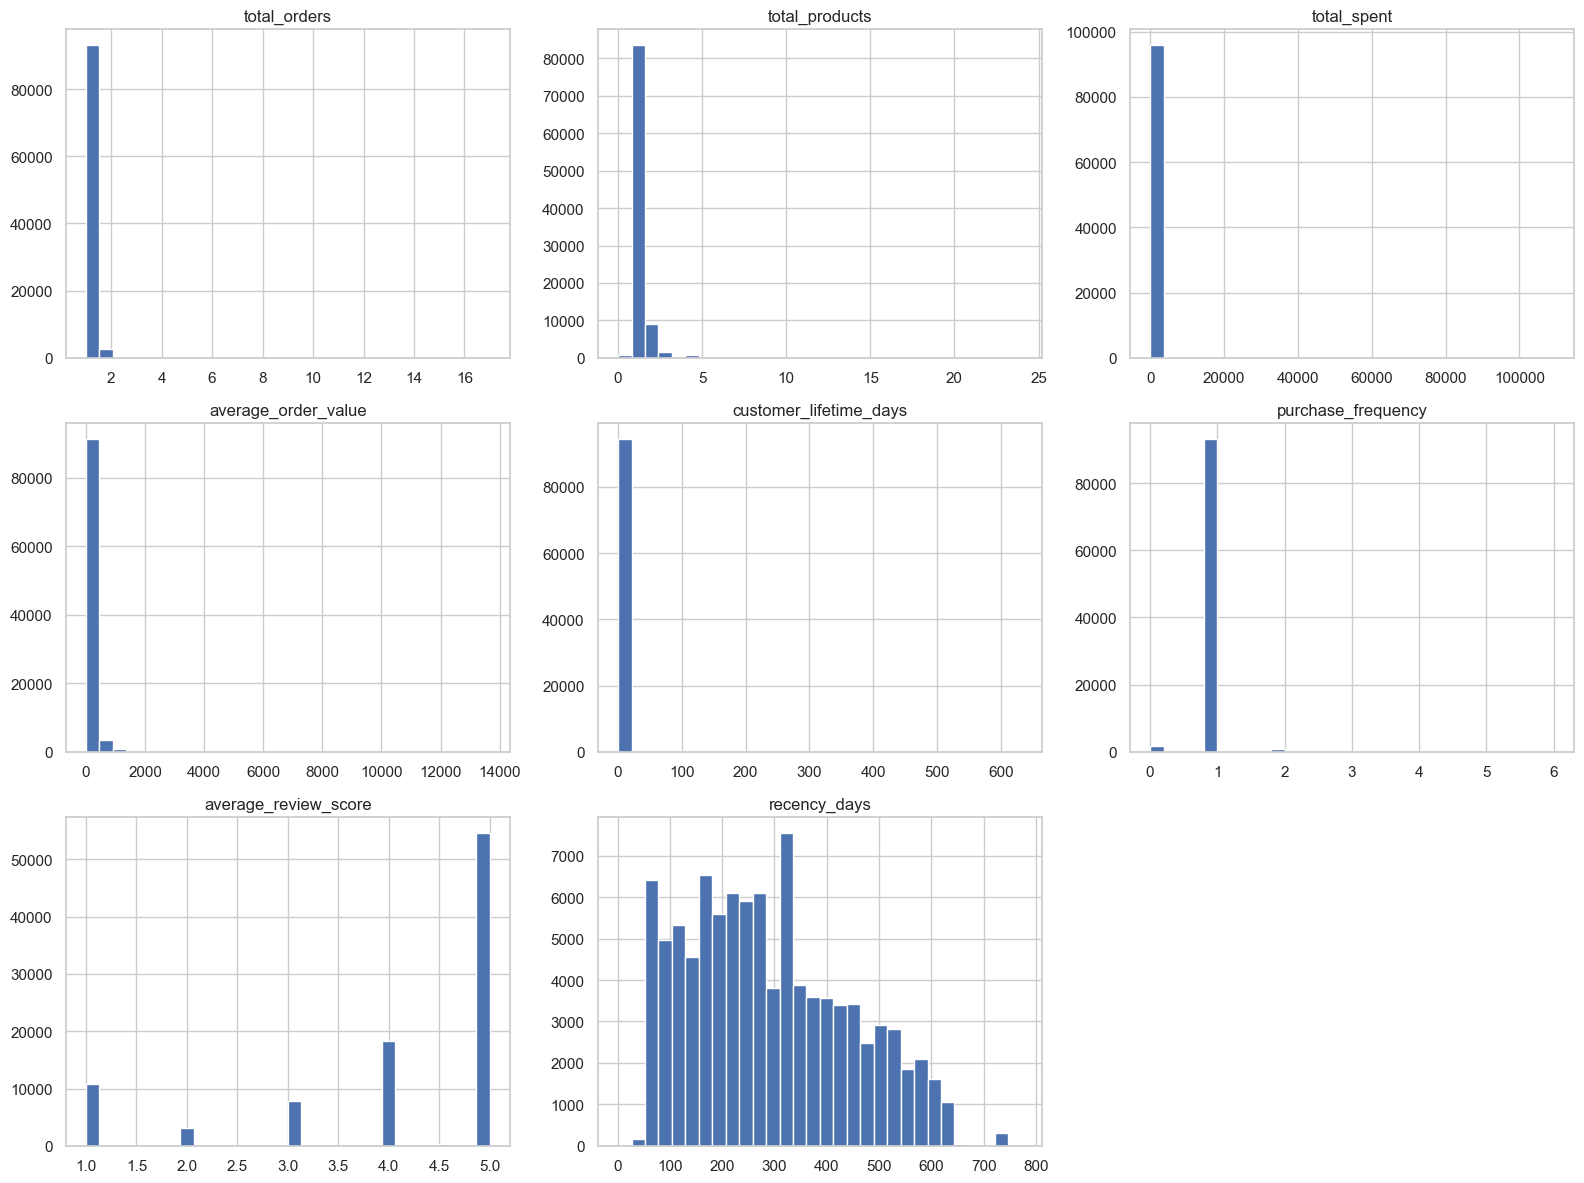

In [61]:
numeric_cols = [
    "total_orders",
    "total_products",
    "total_spent",
    "average_order_value",
    "customer_lifetime_days",
    "purchase_frequency",
    "average_review_score",
    "recency_days"
]

customer[numeric_cols].hist(
    figsize=(16,12),
    bins=30
)

plt.tight_layout()

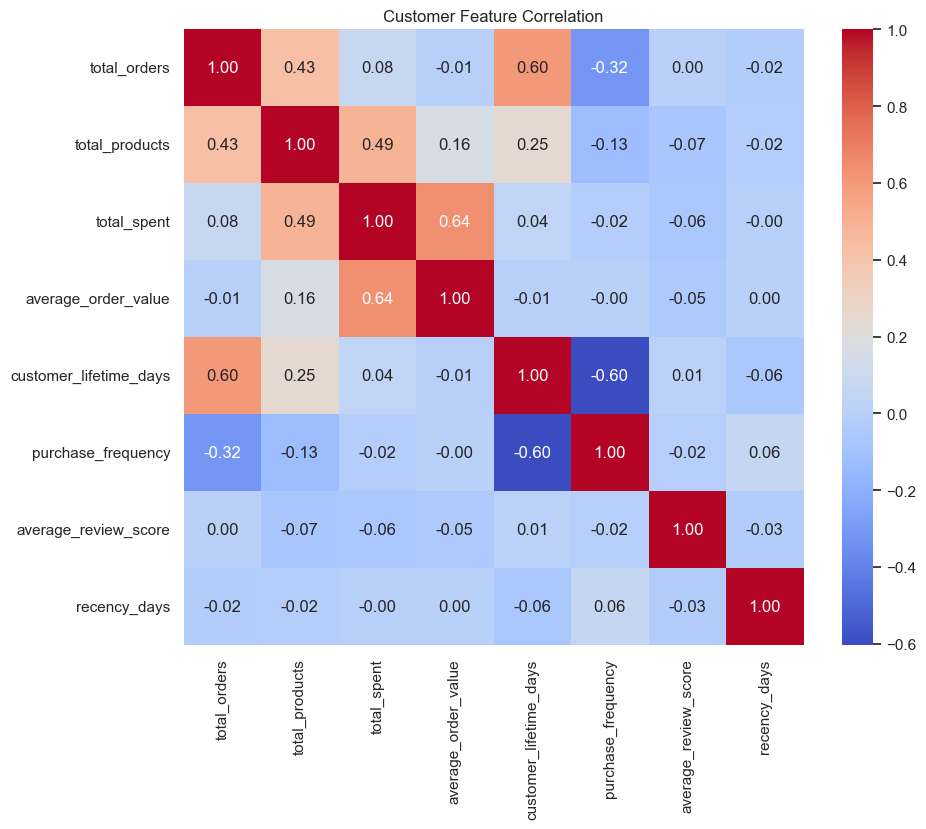

In [62]:
plt.figure(figsize=(10,8))

sns.heatmap(
    customer[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Feature Correlation")
plt.show()

In [63]:
customer["R_score"] = pd.qcut(
    customer["recency_days"],
    5,
    labels=[5,4,3,2,1]
)

In [64]:
customer["F_score"] = pd.qcut(
    customer["total_orders"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [65]:
customer["M_score"] = pd.qcut(
    customer["total_spent"],
    5,
    labels=[1,2,3,4,5]
)

In [66]:
customer["RFM_Score"] = (
    customer["R_score"].astype(str)
    + customer["F_score"].astype(str)
    + customer["M_score"].astype(str)
)

customer[
    [
        "customer_unique_id",
        "R_score",
        "F_score",
        "M_score",
        "RFM_Score"
    ]
].head()

,customer_unique_id,R_score,F_score,M_score,RFM_Score
0,7c396fd4830fd04220f754e42b4e5bff,2,5,2,252
1,af07308b275d755c9edb36a90c618231,5,1,4,514
2,3a653a41f6f9fc3d2a113cf8398680e8,5,1,4,514
3,7c142cf63193a1473d2e66489a9ae977,2,1,2,212
4,72632f0f9dd73dfee390c9b22eb56dd6,3,1,1,311


In [67]:
def segment_customer(rfm):
    if rfm in ["555", "554", "545", "544", "455", "454", "445"]:
        return "Champions"

    elif rfm in ["543","444","435","355","354","345","344"]:
        return "Loyal Customers"

    elif rfm.startswith("5"):
        return "Recent Customers"

    elif rfm.endswith("5"):
        return "Big Spenders"

    elif rfm.startswith("1") and rfm.endswith("1"):
        return "Lost Customers"

    else:
        return "Regular Customers"


customer["segment"] = customer["RFM_Score"].apply(segment_customer)

In [68]:
customer["segment"].value_counts()

segment
Regular Customers    54180
Recent Customers     15154
Big Spenders         11267
Champions             5953
Loyal Customers       5528
Lost Customers        4014
Name: count, dtype: int64

Saved → 01_customer_segments.png


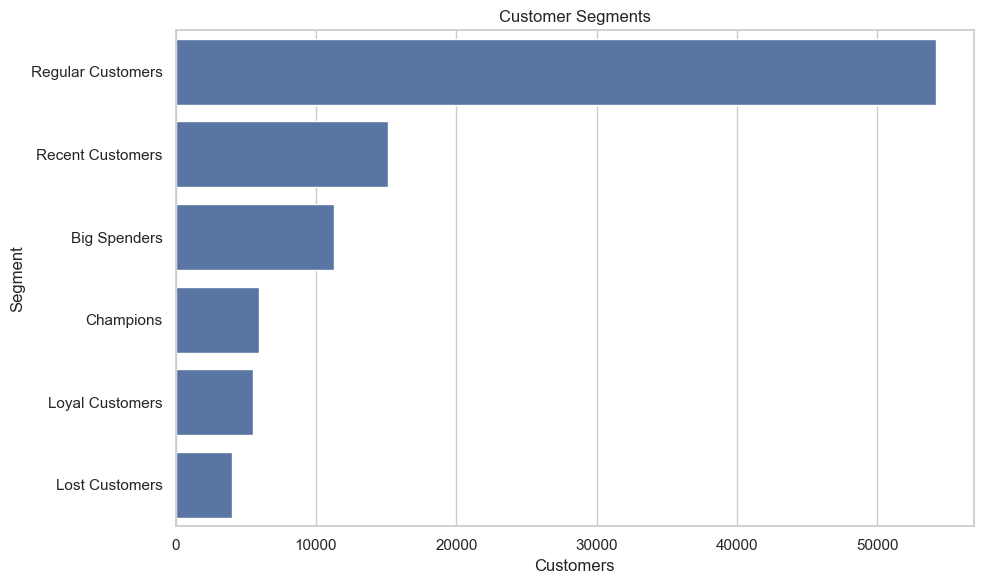

In [69]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=customer,
    y="segment",
    order=customer["segment"].value_counts().index
)

plt.title("Customer Segments")
plt.xlabel("Customers")
plt.ylabel("Segment")

save_plot("01_customer_segments")

Saved → 02_segment_revenue.png


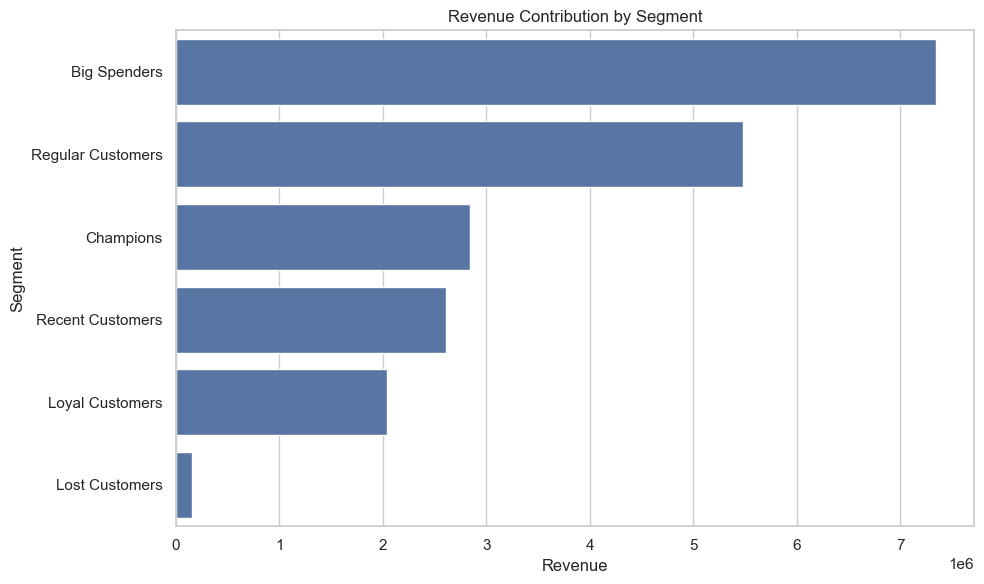

In [70]:
segment_revenue = (
    customer
    .groupby("segment")["total_spent"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_revenue,
    x="total_spent",
    y="segment"
)

plt.title("Revenue Contribution by Segment")
plt.xlabel("Revenue")
plt.ylabel("Segment")

save_plot("02_segment_revenue")

Saved → 03_average_spend_segment.png


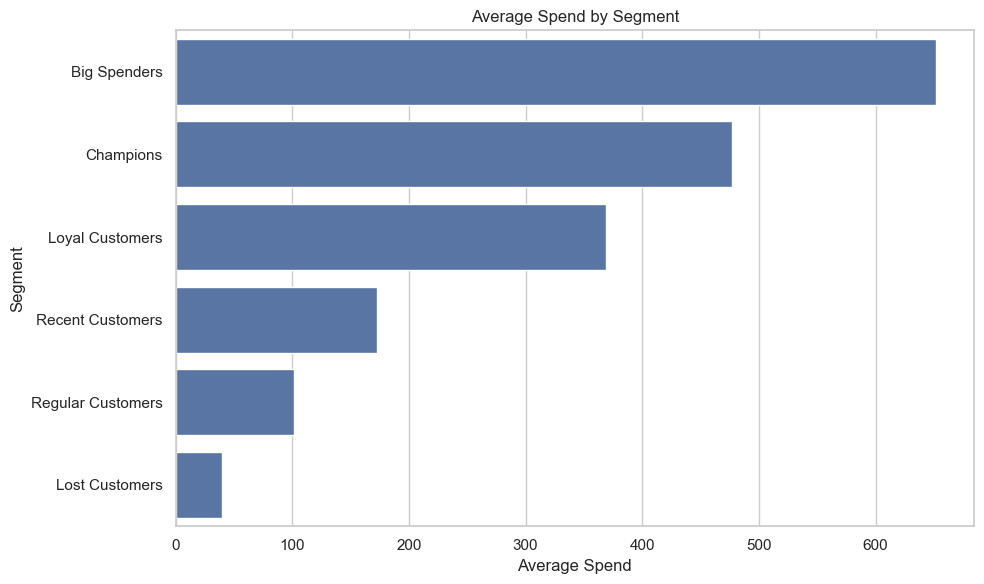

In [71]:
segment_avg = (
    customer
    .groupby("segment")["total_spent"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_avg,
    x="total_spent",
    y="segment"
)

plt.title("Average Spend by Segment")
plt.xlabel("Average Spend")
plt.ylabel("Segment")

save_plot("03_average_spend_segment")

In [72]:
segment_summary = (
    customer
    .groupby("segment")
    .agg(
        customers=("customer_unique_id","count"),
        avg_orders=("total_orders","mean"),
        avg_spent=("total_spent","mean"),
        avg_review=("average_review_score","mean")
    )
    .sort_values("customers", ascending=False)
)

segment_summary


,customers,avg_orders,avg_spent,avg_review
segment,,,,
Regular Customers,54180,1.014747,101.061191,4.096249
Recent Customers,15154,1.008447,172.177122,4.286948
Big Spenders,11267,1.050856,651.856390,3.840872
Champions,5953,1.213002,477.202174,4.051810
Loyal Customers,5528,1.102750,369.113464,3.887716
Lost Customers,4014,1.002242,39.947564,4.164368


In [73]:
features = [
    "recency_days",
    "total_orders",
    "total_spent",
    "customer_lifetime_days",
    "purchase_frequency",
]
X = customer[features].copy()

X.head()

,recency_days,total_orders,total_spent,customer_lifetime_days,purchase_frequency
0,381,2,82.82,27,0.0741
1,85,1,141.46,0,1.0000
2,71,1,179.12,0,1.0000
3,333,1,72.20,0,1.0000
4,246,1,28.62,0,1.0000


In [74]:
X.isnull().sum()

recency_days              0
total_orders              0
total_spent               0
customer_lifetime_days    0
purchase_frequency        0
dtype: int64

In [75]:
X = X.fillna(X.median(numeric_only=True))

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [77]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

Saved → 04_elbow_method.png


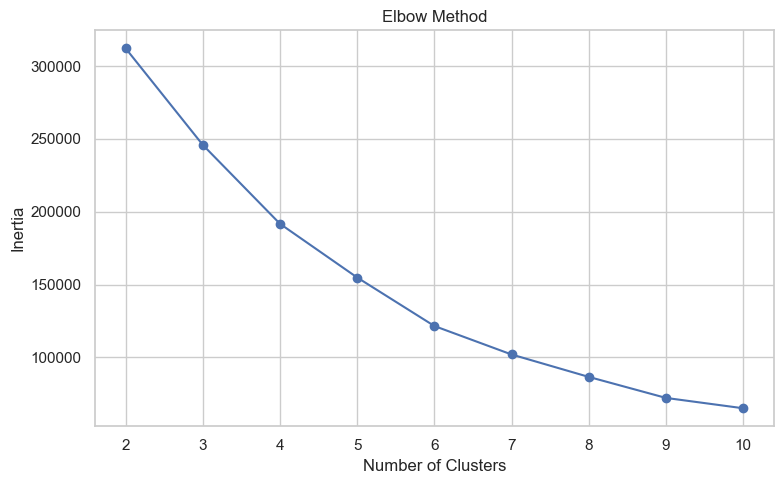

In [78]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

save_plot("04_elbow_method")

In [79]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

customer["cluster"] = kmeans.fit_predict(X_scaled)

In [80]:
customer["cluster"].value_counts().sort_index()

cluster
0    39502
1    53656
2     2005
3      915
4       18
Name: count, dtype: int64

Saved → 05_cluster_distribution.png


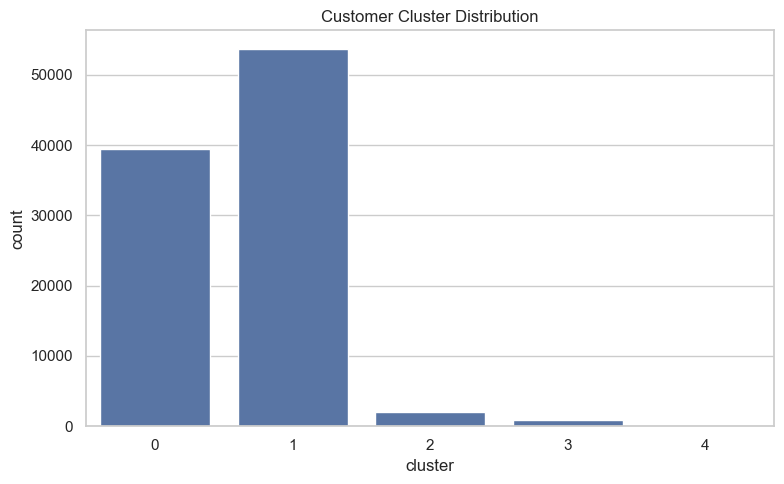

In [81]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer,
    x="cluster"
)

plt.title("Customer Cluster Distribution")

save_plot("05_cluster_distribution")

In [82]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

customer["PC1"] = X_pca[:,0]
customer["PC2"] = X_pca[:,1]

Saved → 06_pca_clusters.png


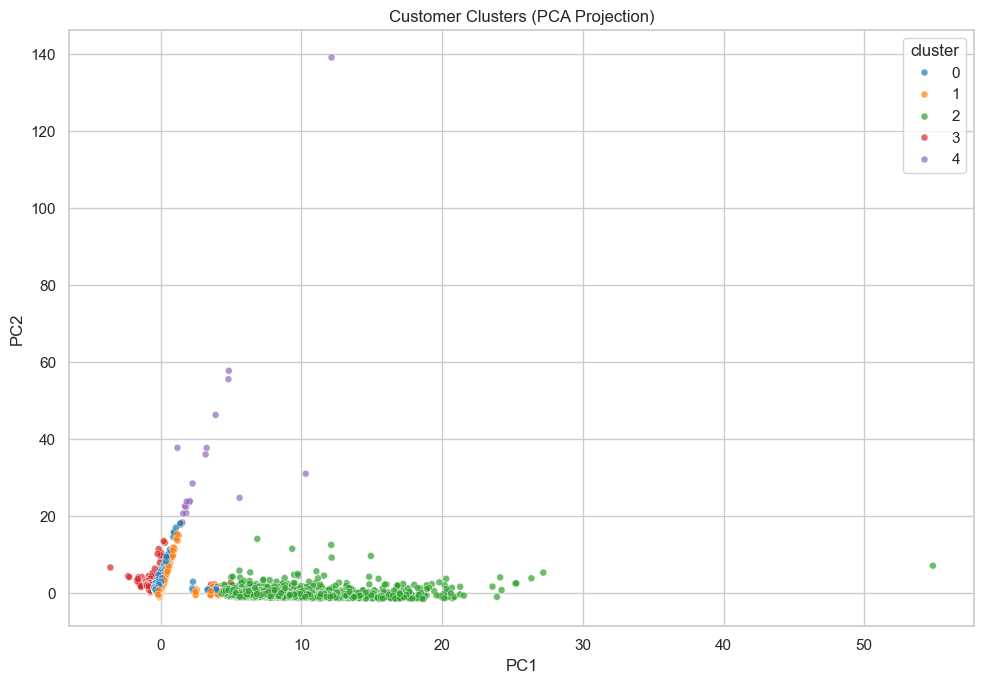

In [83]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=customer,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=25,
    alpha=0.7
)

plt.title("Customer Clusters (PCA Projection)")

save_plot("06_pca_clusters")

In [84]:
cluster_profile = (
    customer
    .groupby("cluster")
    .agg({
        "total_orders":"mean",
        "total_spent":"mean",
        "average_order_value":"mean",
        "purchase_frequency":"mean",
        "customer_lifetime_days":"mean",
        "recency_days":"mean",
        "average_review_score":"mean"
    })
    .round(2)
)

cluster_profile

,total_orders,total_spent,average_order_value,purchase_frequency,customer_lifetime_days,recency_days,average_review_score
cluster,,,,,,,
0,1.00,201.57,162.02,1.00,0.00,439.45,4.08
1,1.00,199.70,160.72,1.00,0.00,178.85,4.09
2,2.15,438.94,153.49,0.06,129.79,236.62,4.18
3,2.04,418.66,146.18,2.04,0.05,340.97,3.93
4,1.28,29453.94,3240.74,1.09,4.72,254.83,2.47


In [85]:
cluster_names = {
    0: "Dormant Customers",
    1: "Loyal Customers",
    2: "Frequent Buyers",
    3: "Premium Customers",
    4: "New Customers"
}

customer["cluster_name"] = customer["cluster"].map(cluster_names)

Saved → 07_customer_segments_named.png


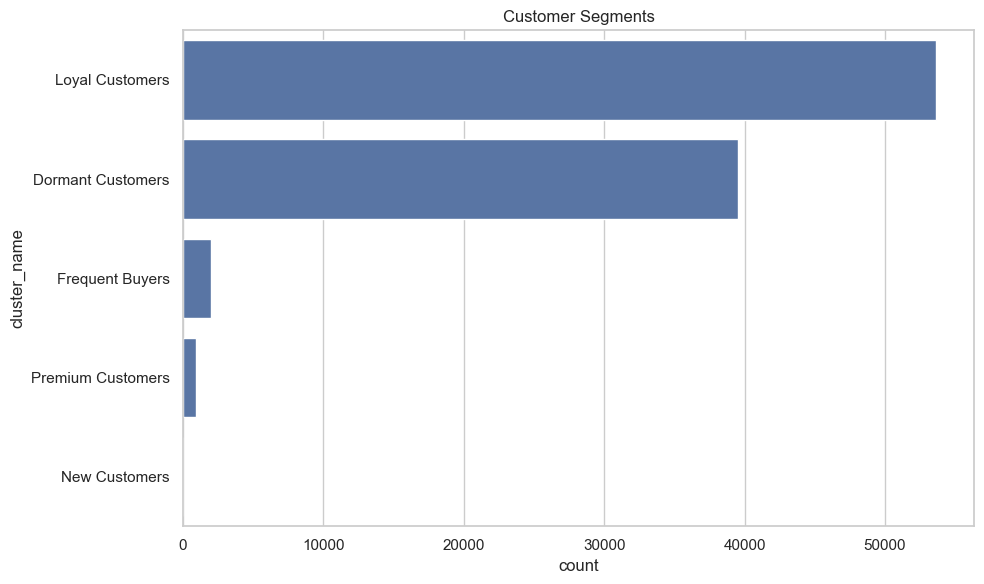

In [86]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=customer,
    y="cluster_name",
    order=customer["cluster_name"].value_counts().index
)

plt.title("Customer Segments")

save_plot("07_customer_segments_named")

In [87]:
cluster_revenue = (
    customer
    .groupby("cluster_name")["total_spent"]
    .sum()
    .sort_values(ascending=False)
)

cluster_revenue

cluster_name
Loyal Customers      10714952.09
Dormant Customers     7962444.43
Frequent Buyers        880083.35
New Customers          530170.91
Premium Customers      383075.88
Name: total_spent, dtype: float64

Saved → 08_cluster_revenue.png


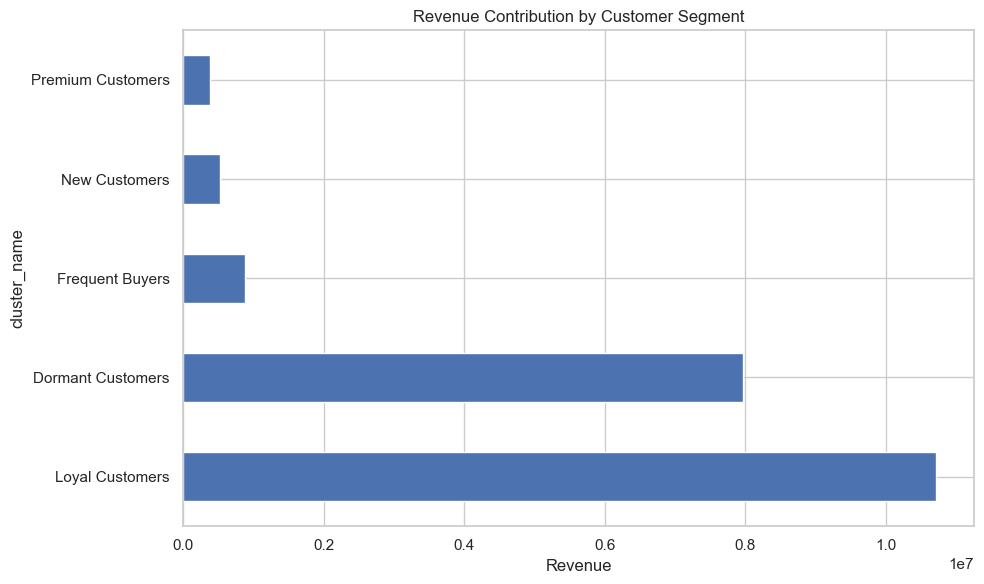

In [88]:
plt.figure(figsize=(10,6))

cluster_revenue.plot(kind="barh")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Revenue")

save_plot("08_cluster_revenue")

In [89]:
import joblib

joblib.dump(kmeans, "../models/customer_segmentation_kmeans.pkl")
joblib.dump(scaler, "../models/customer_segmentation_scaler.pkl")

['../models/customer_segmentation_scaler.pkl']

In [90]:
customer.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)